<a href="https://colab.research.google.com/github/Diego-Cano-bit/CIMAT-Monterrey/blob/main/CNN_Propuesta_CIMAT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
version = 'VGG19'

In [ ]:
from scipy.fftpack import fft, ifft
import scipy.signal
from scipy.signal import butter,lfilter,freqz
import numpy as np
import matplotlib.pyplot as plt

class SignalProcessing:
    def __init__(self, fs):
        self.fs = fs

    def butter_lowpass(self, cutoff, fs, order=5):
        return scipy.signal.butter(order, cutoff, fs=fs, btype='low', analog=False)

    def butter_lowpass_filter(self, data, cutoff, fs, order=5):
        b, a = self.butter_lowpass(cutoff, fs, order=order)
        y = scipy.signal.lfilter(b, a, data)
        return y

    def power_spectrum(self, y_signal, fs, time):
        t = np.arange(-time, time, 1/fs)
        L = len(t)
        n = 2^int(np.ceil(np.log2(L)))
        Y = np.fft.fft(y_signal, n)
        f = fs * (np.arange(n//2 +1)) / n
        P = np.abs(Y/n)
        frec = f
        Power = P[1:n / 2+1]

        plt.figure()
        plt.plot(frec, Power)
        plt.xlabel('Frecuencia')
        plt.ylabel('Potencia espectral')
        plt.title('Espectro de potencia')
        plt.show()

    def image_to_array(self, imagen):
        size = (64, 64)
        fig = plt.figure(figsize=(size[1]/100, size[0]/100))
        ax = plt.Axes(fig, [0., 0., 1., 1.])
        ax.set_axis_off()
        fig.add_axes(ax)

        plt.specgram(np.array(imagen).flatten(), Fs=self.fs, cmap="gray")

        fig.canvas.draw()
        arr = np.array(fig.canvas.renderer.buffer_rgba())
        gray_arr = np.dot(arr[..., :3], [0.2989, 0.5870, 0.1140])

        # Redimensiona el arreglo al tamaño deseado
        resized_arr = np.resize(gray_arr, size)
        plt.close(fig)
        # Retorna el arreglo redimensionado
        return resized_arr

In [ ]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from time import sleep
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras.regularizers import l2
from keras.optimizers import Adam

# Leer  archivos CSV
normal_signals_dt = pd.read_csv('/content/drive/MyDrive/entrenamientos/DATASETS/normal_signals.csv')
abnormal_signals_dt = pd.read_csv('/content/drive/MyDrive/entrenamientos/DATASETS/abnormal_signals.csv')

normal_signals_data = normal_signals_dt.to_numpy()
abnormal_signals_data = abnormal_signals_dt.to_numpy()

final_normal_signals = []
final_abnormal_signals = []

cutoff = 2*np.pi*60 #frecuencia de corte rad/s
fs = 2*np.pi*125 #sampling frequency rad/s

signal_processor = SignalProcessing(fs)

for row in normal_signals_data:
    spectogram = signal_processor.image_to_array(row)
    final_normal_signals.append(spectogram)

for row in abnormal_signals_data:
    spectogram = signal_processor.image_to_array(row)
    final_abnormal_signals.append(spectogram)

print("Tamaño de señales normales:", len(final_normal_signals))
print("Tamaño de señales anormales:", len(final_abnormal_signals))
# Convertir las listas de espectrogramas en arrays

X_normal = np.array(final_normal_signals)
X_abnormal = np.array(final_abnormal_signals)

# Crear las etiquetas (0 normales y 1 anormales)
y_normal = np.zeros(len(X_normal))
y_abnormal = np.ones(len(X_abnormal))

# Concatenar los datos y las etiquetas
X = np.concatenate((X_normal, X_abnormal), axis=0)
y = np.concatenate((y_normal, y_abnormal), axis=0)

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)

X_test, X_val, y_test, y_val = train_test_split(X_temp, y_temp, test_size=0.6, random_state=42)

# len(X_train)
print("Tamaño x_train", len(X_train))
print("Tamaño x_test", len(X_test))
print("tamaño x_val", len(X_val))
# Normalizar
X_train = X_train / 255
X_test = X_test / 255
X_val = X_val / 255

# Imprimir las formas de los conjuntos de datos de entrenamiento y prueba
print("Forma de X_train:", X_train.shape)
print("Forma de y_train:", y_train.shape)
print("Forma de X_test:", X_test.shape)
print("Forma de y_test:", y_test.shape)
print("Forma de X_test:", X_val.shape)
print("Forma de y_test:", y_val.shape)


<ipython-input-3-c31d553e32b2>:43: UserWarning: Only one segment is calculated since parameter NFFT (=256) >= signal length (=256).
  plt.specgram(np.array(imagen).flatten(), Fs=self.fs, cmap="gray")


Tamaño de señales normales: 4044
Tamaño de señales anormales: 4044
Tamaño x_train 5661
Tamaño x_test 970
tamaño x_val 1457
Forma de X_train: (5661, 64, 64)
Forma de y_train: (5661,)
Forma de X_test: (970, 64, 64)
Forma de y_test: (970,)
Forma de X_test: (1457, 64, 64)
Forma de y_test: (1457,)


In [ ]:

import numpy as np
fs = 2*np.pi*125
print(fs)

785.3981633974482


CIMAT

In [ ]:
model = tf.keras.models.Sequential([
         #Aplicar filtros altos en esta parte
     tf.keras.layers.Conv2D(filters=512, kernel_size=3, activation='relu', padding='same',input_shape=(64, 64,1)),
     tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same',),
     tf.keras.layers.MaxPool2D(),
     tf.keras.layers.Dropout(0.2),

     # Block Two
     tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same',),
     tf.keras.layers.MaxPool2D(),
     tf.keras.layers.Dropout(0.2),

     # Head Red normal, solo hacer filtos pequeños porque es una clasificación binaria
     tf.keras.layers.Flatten(),
     tf.keras.layers.Dense(1024, activation='relu'),
     tf.keras.layers.Dropout(0.5),
     tf.keras.layers.Dense(1024, activation='relu'),
     tf.keras.layers.Dropout(0.5),
     tf.keras.layers.Dense(1, activation='sigmoid'),
     #tf.keras.layers.Dense(2, activation='softmax'),
 ])

print(model.summary())

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_80 (Conv2D)          (None, 64, 64, 512)       5120      
                                                                 
 conv2d_81 (Conv2D)          (None, 64, 64, 128)       589952    
                                                                 
 max_pooling2d_19 (MaxPooli  (None, 32, 32, 128)       0         
 ng2D)                                                           
                                                                 
 dropout_20 (Dropout)        (None, 32, 32, 128)       0         
                                                                 
 conv2d_82 (Conv2D)          (None, 32, 32, 128)       147584    
                                                                 
 max_pooling2d_20 (MaxPooli  (None, 16, 16, 128)       0         
 ng2D)                                                

CIMAT L2

In [ ]:
from tensorflow.keras.regularizers import l2

model = tf.keras.models.Sequential([
    # Aplicar filtros altos en esta parte
    tf.keras.layers.Conv2D(filters=512, kernel_size=3, activation='relu', padding='same', input_shape=(64, 64, 1), kernel_regularizer=l2(0.01)),
    tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.2),

    # Block Two
    tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu', padding='same', kernel_regularizer=l2(0.01)),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.2),

    # Head Red normal, solo hacer filtros pequeños porque es una clasificación binaria
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=l2(0.01)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1024, activation='relu', kernel_regularizer=l2(0.01)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])


**VGG** **19**

In [ ]:
#vgg19
model = tf.keras.models.Sequential([
    # Bloque 1
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same',
                input_shape=(64, 64, 1)),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Bloque 2
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Bloque 3
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Bloque 4
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Bloque 5
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2, 2), strides=(2, 2)),

    # Capa Flatten
    tf.keras.layers.Flatten(),

    # Capas densas
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(4096, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    # Capa de salida
    tf.keras.layers.Dense(1, activation='sigmoid')
])

print(model.summary())


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 64, 64, 64)        640       
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        36928     
                                                                 
 max_pooling2d (MaxPooling2  (None, 32, 32, 64)        0         
 D)                                                              
                                                                 
 conv2d_2 (Conv2D)           (None, 32, 32, 128)       73856     
                                                                 
 conv2d_3 (Conv2D)           (None, 32, 32, 128)       147584    
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 16, 16, 128)       0         
 g2D)                                                   

**MINIST TEST**

In [ ]:
#MINIST TEST
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu', input_shape=(64, 64,1)),
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu'),
    tf.keras.layers.MaxPool2D(strides=(2,2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

print(model.summary())

Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_60 (Conv2D)          (None, 64, 64, 32)        832       
                                                                 
 conv2d_61 (Conv2D)          (None, 64, 64, 32)        25632     
                                                                 
 max_pooling2d_12 (MaxPooli  (None, 32, 32, 32)        0         
 ng2D)                                                           
                                                                 
 dropout_15 (Dropout)        (None, 32, 32, 32)        0         
                                                                 
 conv2d_62 (Conv2D)          (None, 32, 32, 64)        18496     
                                                                 
 conv2d_63 (Conv2D)          (None, 32, 32, 64)        36928     
                                                      

**MINISTl2 TEST**

In [ ]:
#MINISTl2 TEST

model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu', input_shape=(64, 64,1), kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Conv2D(32, (5,5), padding='same', activation='relu', kernel_regularizer=l2(0.001)),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.MaxPool2D(strides=(2,2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

RESNET


In [ ]:
#ResNet
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, ReLU, MaxPooling2D, GlobalAveragePooling2D, Dense, Add
from tensorflow.keras.models import Model

def residual_block(x, filters, kernel_size=3, stride=1):
    # Shortcut
    shortcut = x

    # First convolution
    x = Conv2D(filters, kernel_size=kernel_size, strides=stride, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)

    # Second convolution
    x = Conv2D(filters, kernel_size=kernel_size, padding='same')(x)
    x = BatchNormalization()(x)

    # Add shortcut
    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = Conv2D(filters, kernel_size=1, strides=stride)(shortcut)
    x = Add()([x, shortcut])
    x = ReLU()(x)

    return x

def ResNet(input_shape, num_classes):
    # Input
    inputs = Input(shape=input_shape)

    # Initial convolution
    x = Conv2D(64, 7, strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    # Residual blocks
    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 64, stride=1)
    x = residual_block(x, 128, stride=2)
    x = residual_block(x, 128, stride=1)
    x = residual_block(x, 256, stride=2)
    x = residual_block(x, 256, stride=1)
    x = residual_block(x, 512, stride=2)
    x = residual_block(x, 512, stride=1)

    # Global average pooling
    x = GlobalAveragePooling2D()(x)

    # Output layer
    outputs = Dense(num_classes, activation='sigmoid')(x)

    # Create model
    model = Model(inputs, outputs)
    return model

# Create the ResNet model for binary classification of 64x64 images in grayscale
model = ResNet((64, 64, 1), 1)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import ConvLSTM2D, MaxPooling3D, Flatten, Dense

model = Sequential()
model.add(ConvLSTM2D(32, (3, 3), activation='relu'))
model.add(MaxPooling3D((1, 2, 2)))
model.add(ConvLSTM2D(64, (3, 3), activation='relu'))
model.add(MaxPooling3D((1, 2, 2)))
model.add(Flatten())
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


Corre los bloques de aquí abajo


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
import csv
import tensorflow as tf

# Definir el callback EarlyStopping
#early_stopping = EarlyStopping(monitor='val_loss', patience=3)

# Compilar el modelo
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()])

# Entrenar el modelo con EarlyStopping
history = model.fit(X_train,
                    y_train,
                    epochs=350,  # Asegúrate de establecer un número suficientemente alto de épocas
                    verbose=1,
                    validation_data=(X_val, y_val))
                    #callbacks=[early_stopping])  # Falta una coma aquí

# Guardar el modelo
model.save(f'/content/drive/My Drive/modelo{version}.h5')

# Imprimir el historial de entrenamiento
print(history.history)


# Guardar el historial de entrenamiento en un archivo .csv
with open('/content/drive/MyDrive/entrenamientos/historial_entrenamiento_VGG19_350.csv', mode='w', newline='') as file:
    writer = csv.writer(file)
    # Escribir la cabecera
    writer.writerow(['epoch'] + list(history.history.keys()))
    # Escribir los datos
    for i in range(len(history.history['loss'])):
        row = [i + 1] + [history.history[key][i] for key in history.history.keys()]
        writer.writerow(row)



Epoch 1/350
177/177 [==============================] - 30s 90ms/step - loss: 0.6943 - accuracy: 0.4969 - precision: 0.4996 - recall: 0.4512 - val_loss: 0.6937 - val_accuracy: 0.5024 - val_precision: 0.5024 - val_recall: 1.0000
Epoch 2/350
177/177 [==============================] - 13s 73ms/step - loss: 0.6941 - accuracy: 0.4918 - precision: 0.4957 - recall: 0.6304 - val_loss: 0.6933 - val_accuracy: 0.4976 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/350
177/177 [==============================] - 12s 70ms/step - loss: 0.6933 - accuracy: 0.4969 - precision: 0.4996 - recall: 0.4965 - val_loss: 0.6933 - val_accuracy: 0.5024 - val_precision: 0.5024 - val_recall: 1.0000
Epoch 4/350
177/177 [==============================] - 13s 73ms/step - loss: 0.6934 - accuracy: 0.5017 - precision: 0.5039 - recall: 0.5682 - val_loss: 0.6932 - val_accuracy: 0.5024 - val_precision: 0.5024 - val_recall: 1.0000
Epoch 5/350
177/177 [==============================] - 13s 73ms/step - loss: 0.6936 

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


{'loss': [0.6942638754844666, 0.6941195130348206, 0.6933134198188782, 0.6934131383895874, 0.6936161518096924, 0.6934502124786377, 0.6939295530319214, 0.6932651996612549, 0.6932903528213501, 0.6934812664985657, 0.6932435631752014, 0.6933850049972534, 0.6932864189147949, 0.6932544112205505, 0.6931747794151306, 0.6934382915496826, 0.6934738755226135, 0.6931973099708557, 0.6930870413780212, 0.693253219127655, 0.6934348940849304, 0.6932871341705322, 0.6931078433990479, 0.6931614279747009, 0.6931168437004089, 0.6933071613311768, 0.6932687759399414, 0.6932747960090637, 0.6932749152183533, 0.6933537125587463, 0.69317227602005, 0.6931372880935669, 0.6931528449058533, 0.6931657195091248, 0.6932246088981628, 0.6931940317153931, 0.6932762265205383, 0.6932402849197388, 0.6931664347648621, 0.69318687915802, 0.693294882774353, 0.6931867599487305, 0.693165123462677, 0.6931973695755005, 0.6931750774383545, 0.6932224631309509, 0.6931960582733154, 0.6931846737861633, 0.6932173371315002, 0.693218827247619

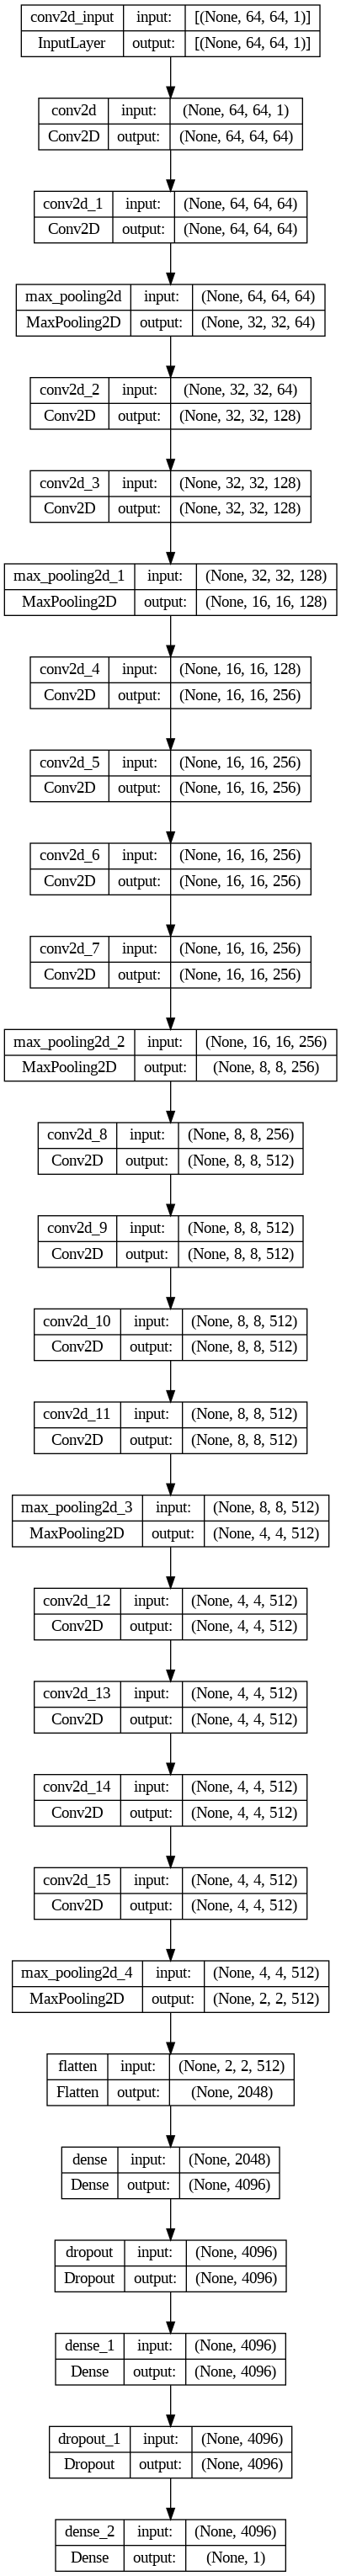

In [ ]:
from tensorflow.keras.utils import plot_model
plot_model(model,
           to_file=f'/content/drive/My Drive/model_{version}_architecture.png',
           show_shapes=True,
           show_layer_names=True)

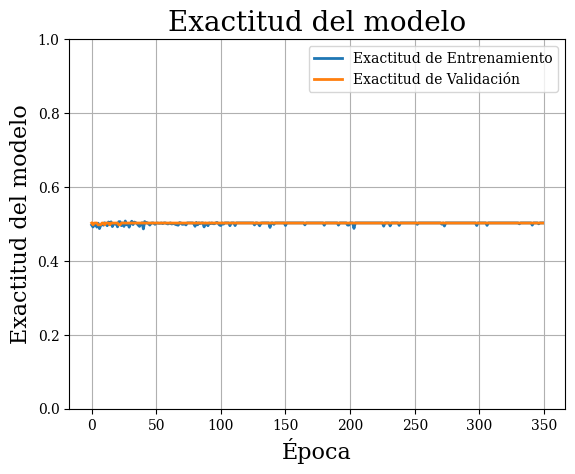

In [ ]:
# Graficar accuracy
# Configurar tipografía Times
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plt.figure()

plt.ylim(bottom=0)
plt.plot(history.history['accuracy'], label='Exactitud de Entrenamiento', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Exactitud de Validación', linewidth=2)
plt.grid()
plt.title('Exactitud del modelo', fontsize=20)
plt.xlabel('Época', fontsize=16)
plt.ylabel('Exactitud del modelo', fontsize=16)
plt.legend()
plt.savefig(f'/content/drive/My Drive/model_{version}_accuracy.png')

plt.show()


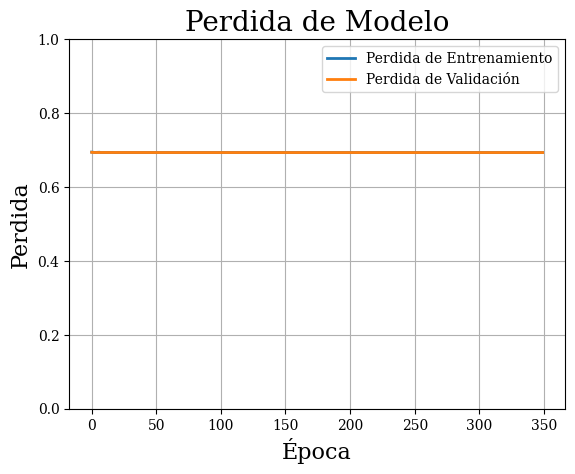

In [ ]:
# Graficar la pérdida del entrenamiento y la validación

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plt.figure()
plt.ylim(bottom=0)
plt.plot(history.history['loss'], label='Perdida de Entrenamiento', linewidth=2)
plt.plot(history.history['val_loss'], label='Perdida de Validación', linewidth=2)
plt.grid()
plt.title('Perdida de Modelo', fontsize=20)
plt.xlabel('Época', fontsize=16)
plt.ylabel('Perdida', fontsize=16)
plt.legend()
plt.savefig(f'/content/drive/My Drive/model_{version}_loss.png')
plt.show()


In [ ]:
print(history.history.keys())

NameError: name 'history' is not defined

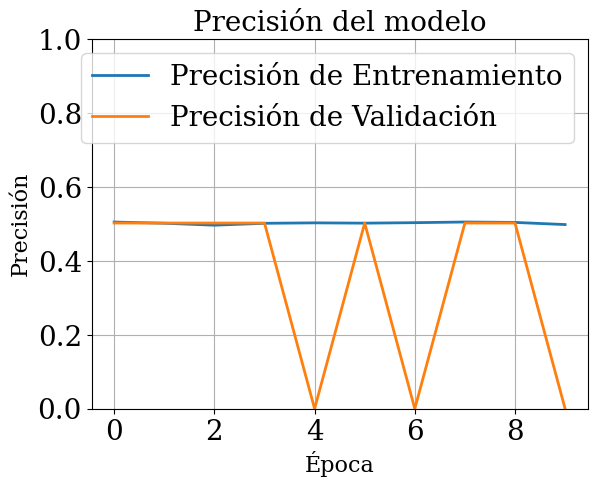

In [ ]:
# Graficar la precisión y la sensibilidad

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plt.figure()
plt.ylim(bottom=0)
plt.plot(history.history['precision_16'], label='Precisión de Entrenamiento', linewidth=2)
plt.plot(history.history['val_precision_16'], label='Precisión de Validación', linewidth=2)
plt.grid()
plt.title('Precisión del modelo', fontsize=20)
plt.xlabel('Época', fontsize=16)
plt.ylabel('Precisión', fontsize=16)
plt.legend()
plt.savefig(f'/content/drive/My Drive/model_{version}_precision.png')
plt.show()


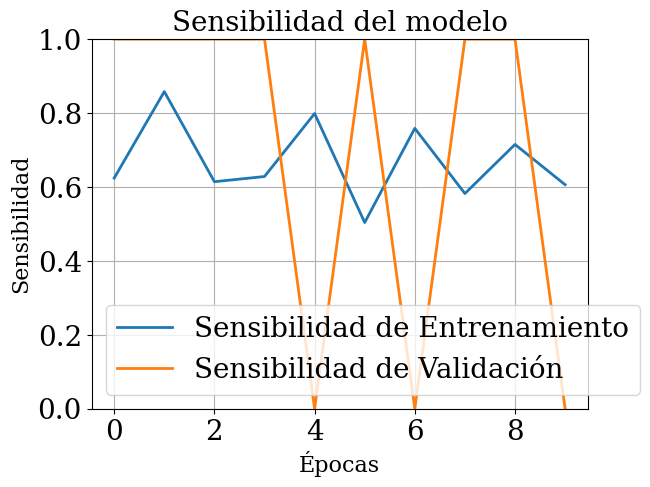

In [ ]:

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

plt.figure()
plt.ylim(bottom=0)
plt.plot(history.history['recall_16'], label='Sensibilidad de Entrenamiento', linewidth=2)
plt.plot(history.history['val_recall_16'], label='Sensibilidad de Validación', linewidth=2)
plt.grid()
plt.title('Sensibilidad del modelo', fontsize=20)
plt.xlabel('Épocas', fontsize=16)
plt.ylabel('Sensibilidad', fontsize=16)
plt.legend()
plt.savefig(f'/content/drive/My Drive/model_{version}_sensibilidad.png')
plt.show()

In [ ]:
# Predicciones como probabilidades
y_pred_prob = model.predict(X_test)

# Convertir probabilidades a etiquetas binarias
y_pred = (y_pred_prob > 0.5).astype(int)

31/31 [==============================] - 1s 18ms/step


In [ ]:
from sklearn.metrics import confusion_matrix

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)

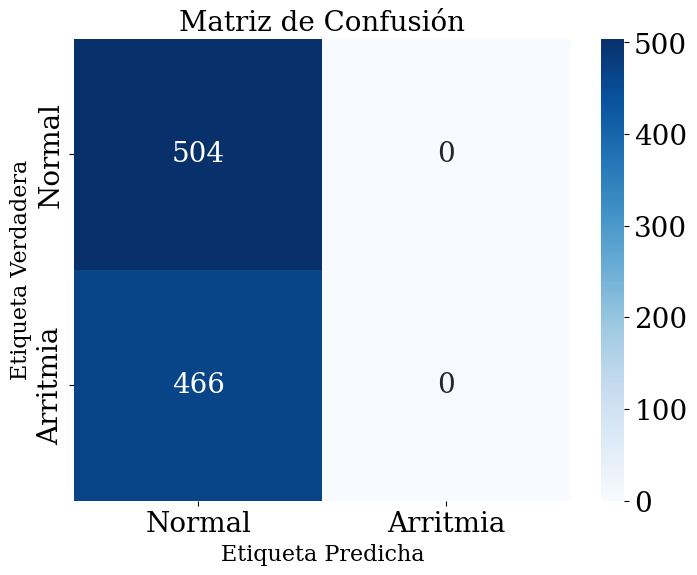

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']


plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Arritmia'], yticklabels=['Normal', 'Arritmia'])
plt.title('Matriz de Confusión', fontsize=20)
plt.ylabel('Etiqueta Verdadera', fontsize=16)
plt.xlabel('Etiqueta Predicha', fontsize=16)

plt.savefig(f'/content/drive/My Drive/model_{version}_matriz.png')

plt.show()

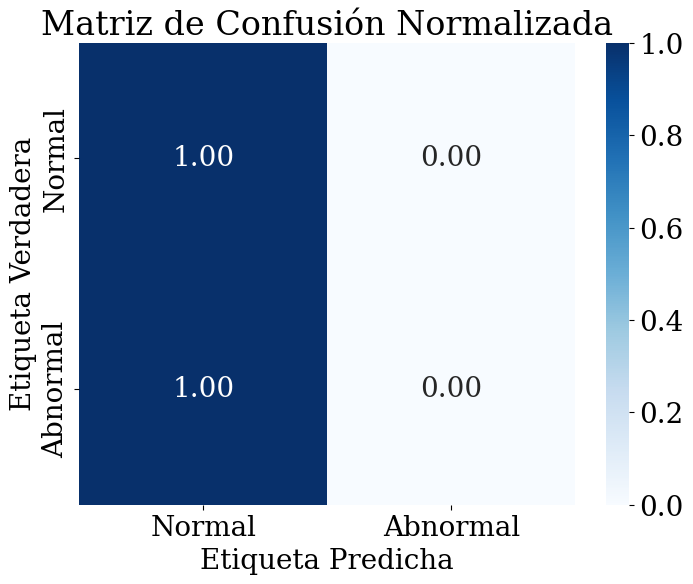

In [ ]:
#Matriz de confusión normalizada
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']


plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', xticklabels=['Normal', 'Abnormal'], yticklabels=['Normal', 'Abnormal'])
plt.title('Matriz de Confusión Normalizada')
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.savefig(f'/content/drive/My Drive/model_{version}_matriznormalizada.png')
plt.show()

 El AUC es : 0.50


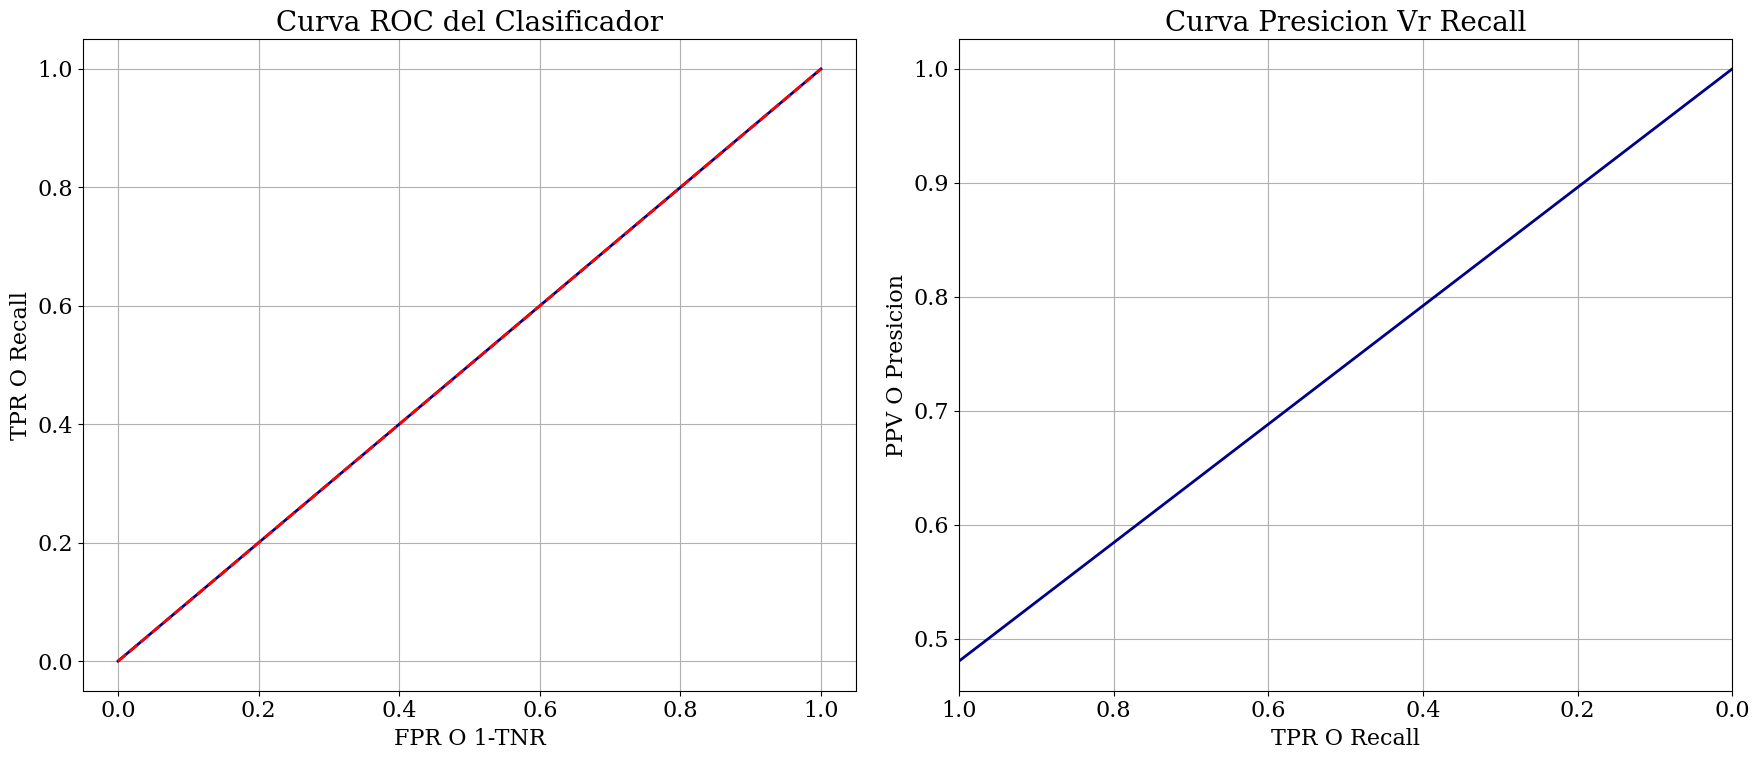

In [ ]:
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
import matplotlib.pyplot as plt

# Configurar tipografía y tamaño de los títulos
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams['font.size'] = 20

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob, pos_label=1)
precision, recall, thresholds2 = precision_recall_curve(y_test, y_pred_prob, pos_label=1)
print(f' El AUC es : {auc(fpr, tpr):,.2f}')


fig, (ax1 , ax2) = plt.subplots(1, 2, figsize=(18, 8))

ax1.set_title('Curva ROC del Clasificador', fontsize=20)
ax1.set_xlabel('FPR O 1-TNR', fontsize=16)
ax1.set_ylabel('TPR O Recall', fontsize=16)
ax1.plot(fpr, tpr, color='darkblue', lw=2)
ax1.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')
ax1.grid()
ax1.tick_params(axis='both', which='major', labelsize=16)


ax2.set_title('Curva Presicion Vr Recall', fontsize=20)
ax2.set_xlabel('TPR O Recall', fontsize=16)
ax2.set_ylabel('PPV O Presicion', fontsize=16)
ax2.plot(recall, precision, color='darkblue', lw=2)
ax2.grid()
ax2.tick_params(axis='both', which='major', labelsize=16)
ax2.set_xlim(1, 0)

plt.tight_layout()

plt.savefig(f'/content/drive/My Drive/model_{version}_ROC.png')
plt.show()


In [ ]:
# Evaluar el modelo en el conjunto de prueba
results = model.evaluate(X_test, y_test)

# Obtener la pérdida y las métricas de evaluación
Test_loss = results[0]
Test_accuracy = results[1]
Test_precision = results[2]
Test_recall = results[3]

# Imprimir los resultados
print(f"Test loss: {Test_loss}")
print(f"Test accuracy: {Test_accuracy}")
print(f"Test precision: {Test_precision}")
print(f"Test recall: {Test_recall}")

file_path = f'/content/drive/My Drive/entrenamientos/{version}_test_results.csv'

# Guardar los resultados en un archivo .csv
with open(file_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    # Escribir la cabecera
    writer.writerow(['Test loss', 'Test accuracy', 'Test precision', 'Test recall'])
    # Escribir los datos
    writer.writerow([Test_loss, Test_accuracy, Test_precision, Test_recall])



31/31 [==============================] - 1s 21ms/step - loss: 0.6931 - accuracy: 0.5196 - precision_16: 0.0000e+00 - recall_16: 0.0000e+00
Test loss: 0.6931015849113464
Test accuracy: 0.5195876359939575
Test precision: 0.0
Test recall: 0.0
